### Initialize the Workspace

The workspace is a 2D representation of a body cavity. A robot arm is mounted at a fixed base point inside it, with two rigid links of lengths L1 and L2 connected at the elbow joint. Circular obstacles represent organs the arm must avoid.

All distances are in arbitrary units. The arm base sits at the origin; the cavity extends from x ∈ [-75, 75] and y ∈ [0, 100].

In [1]:
from workspace import Robot, Obstacle, Workspace

robot = Robot(base=(0, 0), link_lengths=(40, 30))
obstacles = [
    Obstacle(center_point=(38, 72), radius=16.0),
    Obstacle(center_point=(-42, 68), radius=12.0),
    Obstacle(center_point=(8, 48), radius=7.0),
    Obstacle(center_point=(-22, 38), radius=9.0),
    Obstacle(center_point=(58, 28), radius=10.0),
    Obstacle(center_point=(-52, 22), radius=8.0)
]
ws = Workspace(robot, obstacles=obstacles, bounds=(-75, 75, 0, 100))

### Calculate Forward Kinematics

Forward kinematics answers: *given joint angles (θ1, θ2), where does each part of the arm end up?*

θ1 is the angle of the first link relative to the x-axis. θ2 is the angle of the second link relative to the first, so globally, the second link points in direction θ1 + θ2. Applying basic trigonometry along each link gives the (x, y) position of the elbow and end-effector.

The cell below checks a few configurations and draws the arm at one of them.

θ1=0°  θ2=0°  →  elbow=(np.float64(40.0), np.float64(0.0))  end_eff=(np.float64(70.0), np.float64(0.0))
θ1=90°  θ2=0°  →  elbow=(np.float64(0.0), np.float64(40.0))  end_eff=(np.float64(0.0), np.float64(70.0))
θ1=45°  θ2=-90°  →  elbow=(np.float64(28.28), np.float64(28.28))  end_eff=(np.float64(49.5), np.float64(7.07))


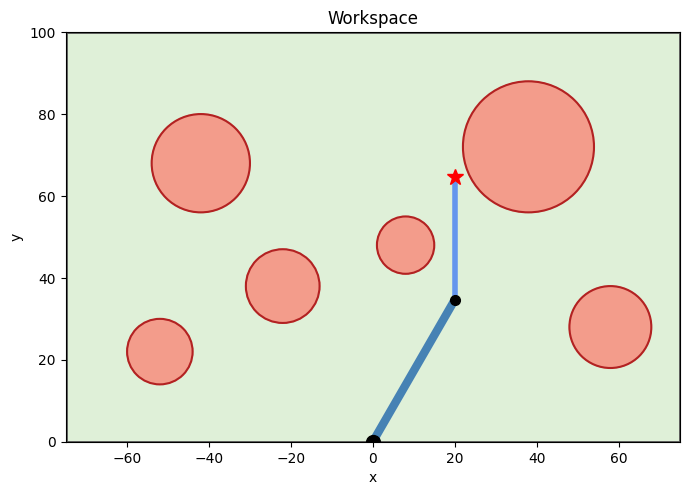

<Axes: title={'center': 'Workspace'}, xlabel='x', ylabel='y'>

In [2]:
import numpy as np
from kinematics import forward_kinematics, inverse_kinematics, is_point_reachable
from visualization import draw_workspace

for t1, t2 in [(0, 0), (np.pi/2, 0), (np.pi/4, -np.pi/2)]:
    elbow, end_eff = forward_kinematics(ws.robot, t1, t2)
    print(f"θ1={np.degrees(t1):.0f}°  θ2={np.degrees(t2):.0f}°  →  elbow={tuple(round(v,2) for v in elbow)}  end_eff={tuple(round(v,2) for v in end_eff)}")

# theta1=60°, theta2=30° — arm points upper-left, clears all obstacles
draw_workspace(ws, theta1=np.pi/3, theta2=np.pi/6)

### Inverse Kinematics

Inverse kinematics answers the reverse question: *given a target point (x, y), what joint angles place the end-effector there?*

The target must lie within the reachable annulus — the ring of points at distances between |L1 − L2| and L1 + L2 from the base. Inside that annulus, there are generally **two solutions**: the elbow can bend left or right to reach the same point. On the annulus boundary (arm fully extended or fully folded) the two solutions coincide and only one is returned.

The cell below finds both solutions for a target and draws them side by side.

Target (40, 30): 2 solution(s)
  [0] θ1=0.0°  θ2=90.0°  →  end_eff=(np.float64(40.0), np.float64(30.0))
  [1] θ1=73.7°  θ2=-90.0°  →  end_eff=(np.float64(40.0), np.float64(30.0))


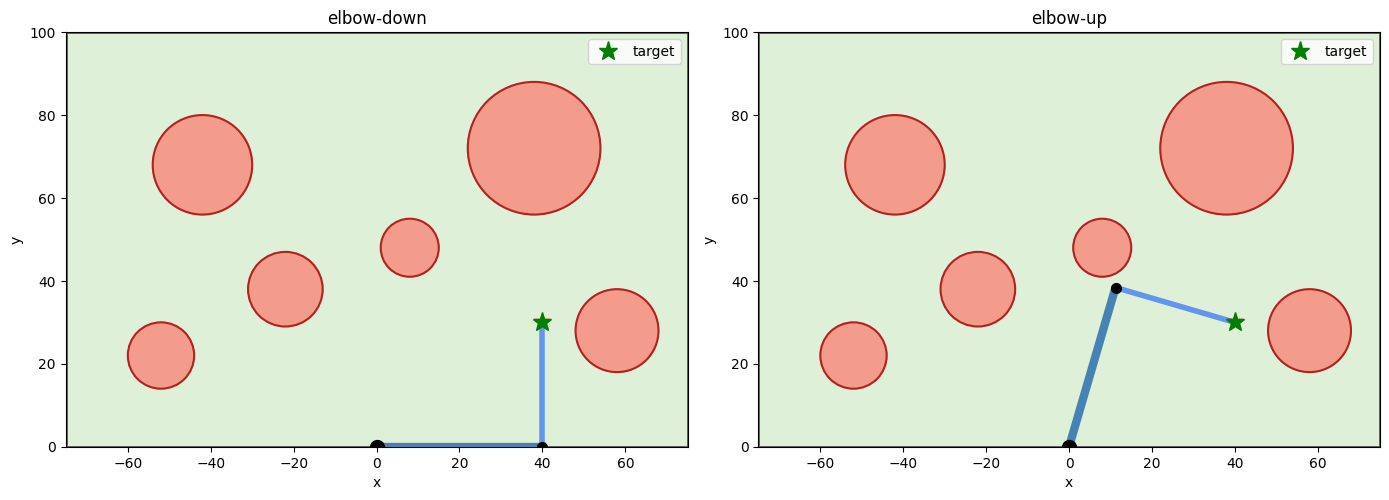


Target (200, 200): reachable=False  solutions=[]


In [3]:
import matplotlib.pyplot as plt

# target must be within the reachable annulus: dist in [|L1-L2|, L1+L2] = [10, 70]
target = (40, 30)  # dist ≈ 50 — comfortably reachable

solutions = inverse_kinematics(ws.robot, *target)
print(f"Target {target}: {len(solutions)} solution(s)")
for i, (t1, t2) in enumerate(solutions):
    elbow, end_eff = forward_kinematics(ws.robot, t1, t2)
    print(f"  [{i}] θ1={np.degrees(t1):.1f}°  θ2={np.degrees(t2):.1f}°  →  end_eff={tuple(round(v,2) for v in end_eff)}")

# draw both elbow solutions side by side
fig, axes = plt.subplots(1, len(solutions), figsize=(7 * len(solutions), 7))
if len(solutions) == 1:
    axes = [axes]
labels = ['elbow-down', 'elbow-up']
for ax, (t1, t2), label in zip(axes, solutions, labels):
    draw_workspace(ws, theta1=t1, theta2=t2, ax=ax, title=label)
    ax.plot(*target, 'g*', ms=14, zorder=5, label='target')
    ax.legend()
plt.tight_layout()
plt.show()

# verify unreachable point
far = (200, 200)
print(f"\nTarget {far}: reachable={is_point_reachable(ws.robot, *far)}  solutions={inverse_kinematics(ws.robot, *far)}")

### Construct the Configuration Space (C-space)

Rather than reasoning about collisions directly in the workspace, the planner operates in **C-space** — a 2D grid where each axis is a joint angle. Every cell (θ1, θ2) in this grid is either **free** (the arm fits without hitting anything) or **in collision** (at least one link intersects an obstacle).

The bitmap is built by running forward kinematics over the entire grid using vectorized operations, then testing each link against every obstacle. Black cells are forbidden configurations; white cells are reachable. Now the planner's goal is to find a path through the white region from start to goal.

Built (400, 400) bitmap in 0.077s
Collision cells: 28,953 / 160,000  (18.1% of C-space is blocked)


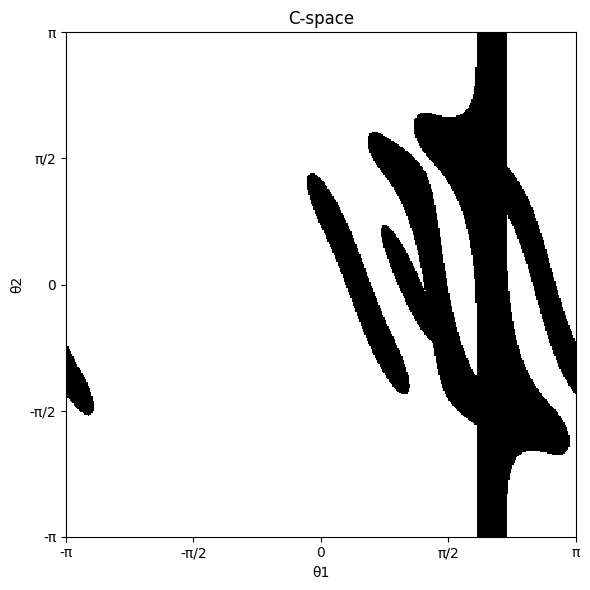

<Axes: title={'center': 'C-space'}, xlabel='θ1', ylabel='θ2'>

In [4]:
import time
from cspace import build_cspace_bitmap
from visualization import draw_cspace

RESOLUTION = 400

t_start = time.time()
bitmap = build_cspace_bitmap(ws, resolution=RESOLUTION)
elapsed = time.time() - t_start

n_collision = bitmap.sum()
n_total = bitmap.size
print(f"Built {bitmap.shape} bitmap in {elapsed:.3f}s")
print(f"Collision cells: {n_collision:,} / {n_total:,}  ({100 * n_collision / n_total:.1f}% of C-space is blocked)")

draw_cspace(bitmap)

### Plan a Path Through C-space

With the C-space bitmap in hand, path planning reduces to graph search. Each free cell is a node; each pair of 8-connected free cells is an edge with cost equal to the Euclidean distance between their center angles. A* with an admissible Euclidean heuristic finds the shortest path in θ-space.

The planner snaps start and goal angles to their containing cells, runs A* on the bitmap, then maps the resulting index sequence back to (θ1, θ2) cell-center angles. The right panel shows the path as a cyan line through C-space; the left panel shows the arm posed at the goal configuration with the target end-effector position marked.

Path: 152 waypoints  |  123.0 ms  |  θ-length = 2.860 rad


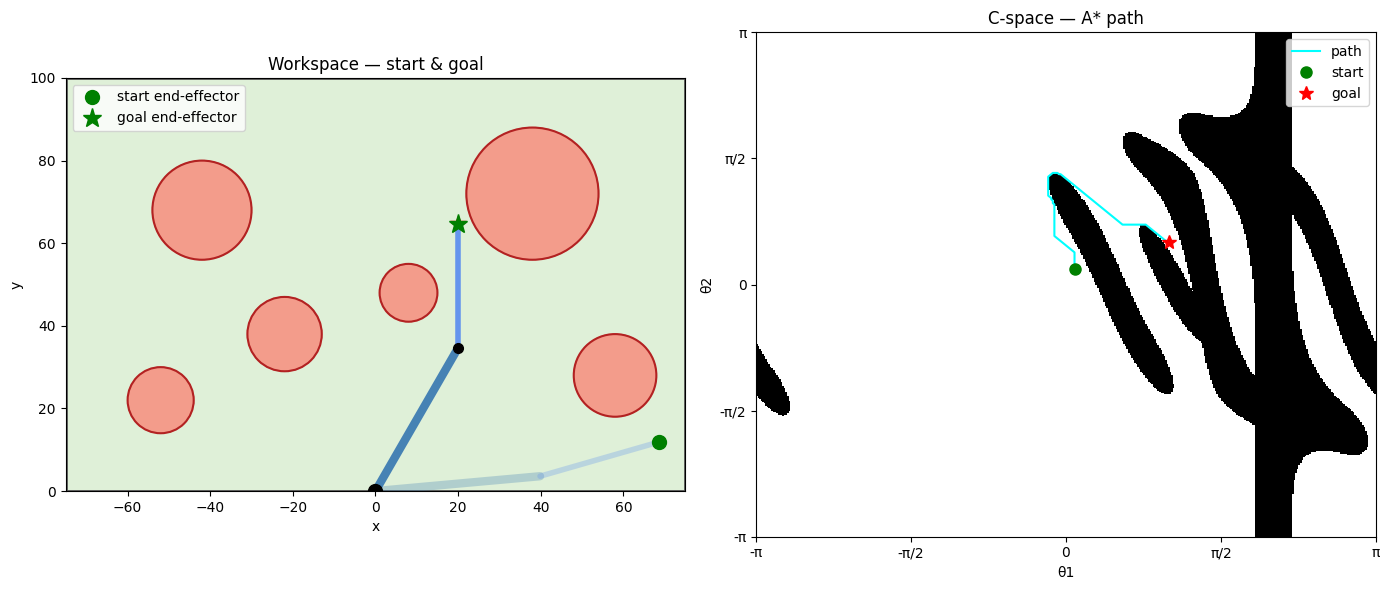

In [5]:
import time
import numpy as np
from path_planning import plan_path
from cspace import config_to_index
from visualization import draw_plan

start_config = (0.09, 0.19)
goal_config  = (np.pi / 3, np.pi / 6)

start_idx = config_to_index(*start_config, RESOLUTION)
goal_idx  = config_to_index(*goal_config,  RESOLUTION)
assert not bitmap[start_idx], f"Start cell {start_idx} is in collision"
assert not bitmap[goal_idx],  f"Goal cell {goal_idx} is in collision"

t0 = time.time()
path = plan_path(bitmap, start_config, goal_config, RESOLUTION)
elapsed = time.time() - t0

if path is None:
    print("No path found — start and goal are in disconnected free regions.")
else:
    thetas = np.array(path)
    diffs  = np.diff(thetas, axis=0)
    path_length = float(np.sum(np.hypot(diffs[:, 0], diffs[:, 1])))
    print(f"Path: {len(path)} waypoints  |  {elapsed * 1000:.1f} ms  |  θ-length = {path_length:.3f} rad")

    draw_plan(ws, bitmap, path, start_config, goal_config)